# Lesson163 · LM encoders for rows

Standalone student lab: three live TODOs, real frozen-encoder evidence and a full three-split head replay. Default execution needs only NumPy/scikit-learn; all inputs are embedded. Fresh BART encoding is a separate opt-in lane (~560 MB weights). Author execution is not learner mastery. Website links become available after publication.

<div class="lab-access"><strong>Lesson package</strong> · <a href="https://avistian.github.io/relational/labs/0163-lm-encoders-for-rows.ipynb">Student notebook</a> · <a href="https://avistian.github.io/relational/labs/html/0163-lm-encoders-for-rows.html">Executed author preview</a> · <a href="https://avistian.github.io/relational/labs/solutions/0163-lm-encoders-for-rows.ipynb">Solution</a><br><a href="https://avistian.github.io/relational/reference/row-encoders.html">Quick reference</a> · <a href="https://avistian.github.io/relational/labs/l163-comparison-template.md">Comparison template</a> · <a href="https://avistian.github.io/relational/labs/l163-reproduction.md">Reproduction contract</a> · <a href="https://avistian.github.io/relational/labs/evidence/l163/report.md">Complete measured results</a></div>

## 1 · What does the row vector remember?

**Single win:** encode the same row as text and as typed features, then defend an encoder choice using predictions and information loss. Read the core lesson in about 10 minutes; do the notebook comparison in a separate practice session.

[Lesson 162](https://avistian.github.io/relational/lessons/0162-the-relational-fm-vision.html) placed a row encoder before graph message passing. That left a gap: what information reaches the graph in the first place? [Lesson 125](https://avistian.github.io/relational/lessons/0125-pytorch-frame-deep-dive.html) introduced semantic column types. Here we compare a numerical value carried as a number with that same value carried through language-model tokens. Recall also [CARTE in Lesson 74](https://avistian.github.io/relational/lessons/0074-carte-cross-table-transfer.html): how you represent a row changes what later computation can use.

Our worked row describes a product: price **10 USD**, weight **2 kg**, colour **red**, condition **used**. A **schema** names and types these fields. An **encoder** turns their values into features a prediction model can use. A **head** is the final fitted mapping from features to the predicted target.

> Before asking which encoder wins, ask what information each path receives, what is fitted, and what stays fixed.

## 2 · Model architecture: two routes from one row

Vogel, Hilprecht and Binnig propose serializing rows together with schema, encoding them with BART, and adding graph context. Their prototype adapts BART on table reconstruction before GNN training. Our comparison isolates the row-input decision: it uses a frozen text-pretrained BART encoder and a typed baseline, with no GNN. The pooling and regression head below are course choices, not a reconstruction of their hidden implementation details. [Primary reading: §§2–4](https://arxiv.org/html/2305.15321v1#S2)

<figure class="route-figure" tabindex="0">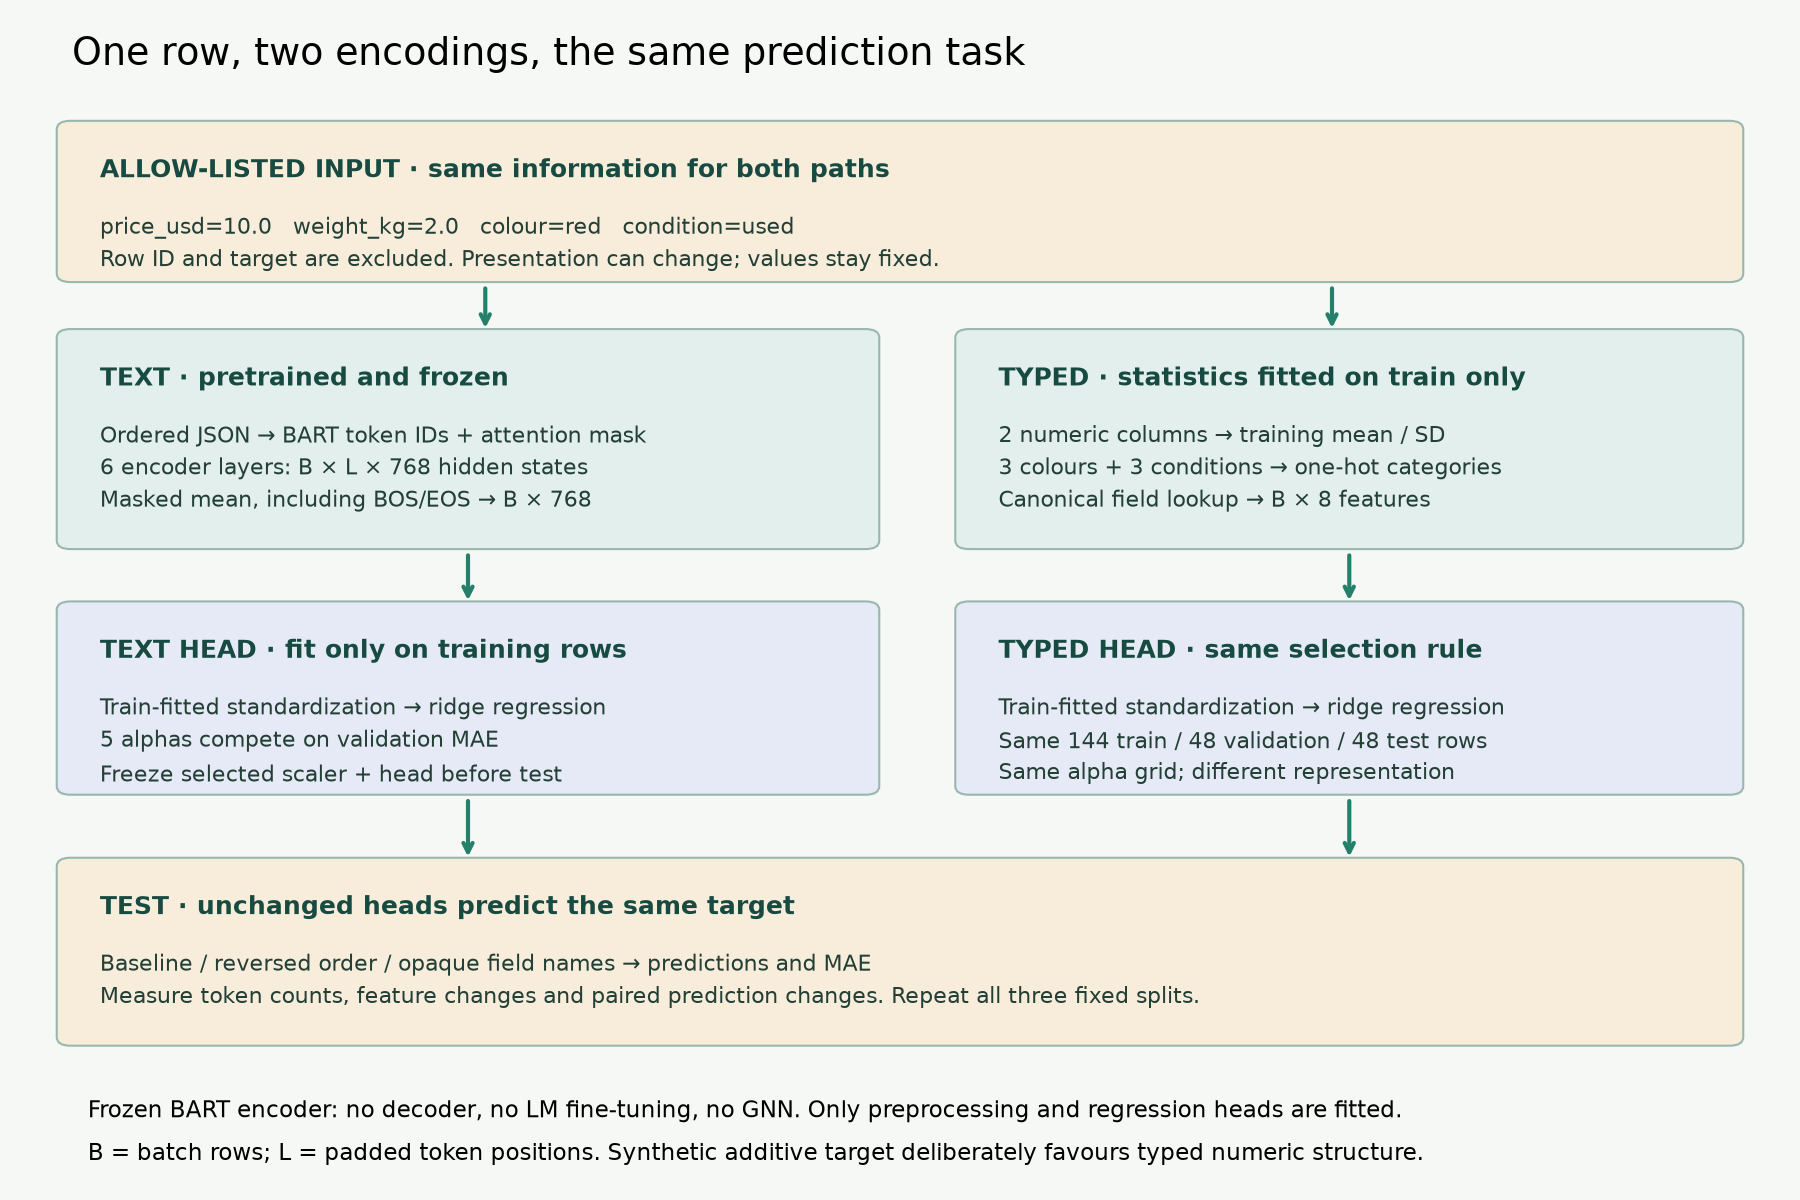<figcaption>The implemented comparison: frozen BART encoder and a train-fitted typed feature map feed separately selected ridge heads. Both use identical splits and target information. This is a local synthetic comparison, not the historical BART_table+GNN model.</figcaption></figure>

**Text route.** We serialize only allowed inputs:

```python
{"table":"products","price_usd":10.0,"weight_kg":2.0,
 "colour":"red","condition":"used"}
```

Serialization must preserve which value belongs to which field. JSON escaping prevents a quoted string from accidentally becoming another field. IDs and the prediction target never enter the text. A tokenizer maps the string to integer token IDs. A token may represent a word fragment, punctuation or part of a number; it is not a typed database cell.

The pinned `facebook/bart-base` encoder has six layers and hidden width 768. For a batch of B rows, padding gives L token positions; final hidden states have shape **B×L×768**. We average real token vectors into **B×768** row features. This pooling is explicit; a generic BART output is not automatically a single row vector. Only the encoder runs. BART's pretrained encoder–decoder design and attention-mask interface are documented in the [model card](https://huggingface.co/facebook/bart-base) and [version-pinned API](https://huggingface.co/docs/transformers/v4.57.1/en/model_doc/bart).

**Typed route.** Fit numeric means/scales and categorical vocabularies on training rows. For each numeric column, compute `z=(value−training_mean)/training_SD`. A category becomes a one-hot block: one position is 1, others 0. With two numeric columns and three values each for colour/condition, our data gives **8 features**. This transparent baseline illustrates type-specific treatment; it is not a trained PyTorch Frame neural encoder.

**Read the units.** SD means standard deviation, a measure of spread around the mean. Subtracting the mean centers a numeric column; dividing by its training SD expresses the value in units of that spread. Using training statistics keeps validation and test values from changing the fitted transform. MAE, used below to select the head, means mean absolute error: average distance between predictions and targets, in target units.

**Worked arithmetic.** If the training price mean is 20 and SD 10, price 10 becomes −1. If weight mean is 1 and SD 0.5, weight 2 becomes 2. With category orders `[blue,green,red]` and `[new,refurbished,used]`, the row becomes `[-1,2,0,0,1,0,0,1]`. These moments are a hand example, not the experiment's fitted statistics. An unseen category produces an all-zero block in our implementation; that policy trades an explicit unknown signal for simplicity.

Both paths then receive training-fitted feature standardization and a ridge head. **Ridge regression** minimizes squared training error plus `alpha × sum(coefficient²)`; the intercept is unpenalized. Larger alpha discourages large coefficients. We choose alpha on validation MAE, then freeze the complete pipeline before testing. Different feature dimensions and pretraining histories mean equal head-selection rules do not imply equal model capacity or compute.

## 3 · Padding, order and names are testable choices

Predict before calculating: vectors [1,3] and [3,7] are real; [900,900] is padding. What should the pooled row contain?

A short row might be padded to match another row in its batch. Padding positions must not enter the average. If token vectors are `[1,3]`, `[3,7]` and padded `[900,900]`, the correct pooled vector is `[2,5]`, not an average of all three. We include BART's beginning/end special tokens and exclude only padding:

```python
pooled = (hidden * mask[:, :, None]).sum(axis=1)
pooled = pooled / mask.sum(axis=1)[:, None]
```

The mask has shape B×L; adding the last axis broadcasts it over 768 features. A zero denominator is an error. Padding exclusion at pooling complements the encoder's attention mask; both matter.

Here **broadcasting** applies the same keep/drop value to every coordinate of one token vector. The attention mask stops padding from being read inside the encoder; the pooling mask stops it from entering the final average. BOS/EOS in the diagram mean beginning/end-of-sequence tokens.

**Now intervene on presentation.** Reverse the field order, or rename the columns to `c0…c3`, preserving every value. A positional text model receives a different sequence. Our typed route looks up canonical field identities, so these presentation changes leave its vector unchanged. That invariance is built into its input mapping. It would not survive an actual loss of field identity.

Portable trace: inspect token_traces below for baseline, reordered and renamed inputs. All values stay fixed; token counts and representations need not.

This explorer shows actual tokenization saved from the pinned BART tokenizer for the first three fixture rows. It runs no model in your browser. Switch a row or schema presentation and inspect token IDs, token count, and the row's precomputed change in pooled features. Token strings use the tokenizer's vocabulary notation; `Ġ` marks a preceding space where present. Dense attention-pair count L² is only a size proxy, not measured end-to-end compute.

**What text can offer.** A pretrained LM is a plausible way to reuse language information in descriptive names and values. That is a hypothesis to test on appropriate data. Turning a number into tokens does not impose arithmetic distance: the character sequence for 20 is not defined to be twice the representation for 10. Conversely, a numeric transform preserves the specified numeric relation but cannot infer the meaning of an unfamiliar product description. Our experiment contains short categories and no free-text descriptions, so it cannot settle that semantic trade-off.

## 4 · A complete, deliberately narrow comparison

We generated **240 synthetic rows** and disclosed the target:

`target = 2×price + 5×weight + condition_offset + colour_offset + noise`

Noise has standard deviation 2. This target is designed to favour a linear numeric/one-hot representation. It tests whether the LM path makes a simple numeric relationship easier or harder to recover; it is not a neutral tournament across all tabular tasks.

For each of three fixed splits, both methods get 144 training, 48 validation and 48 test rows. Preprocessing uses training rows only. Five alphas (`0.01,0.1,1,10,100`) compete on validation MAE. We keep the selected training-only head without refitting on validation. Reordered/renamed test text goes through that **same head**. MAE is the average absolute prediction error in synthetic target units; lower is better. [Exact protocol and commands](https://avistian.github.io/relational/labs/l163-reproduction.md)

| Encoder | Input presentation | Mean MAE ± split SD | Mean absolute prediction change |
|---|---|---:|---:|
| typed | baseline | 1.714 ± 0.151 | 0.000 |
| typed | reordered | 1.714 ± 0.151 | 0.000 |
| typed | renamed | 1.714 ± 0.151 | 0.000 |
| bart | baseline | 14.265 ± 1.285 | 0.000 |
| bart | reordered | 55.051 ± 34.406 | 50.765 |
| bart | renamed | 705.122 ± 81.466 | 705.388 |

All 720 row encodings and all six head selections completed. Fresh encoding took 36.2 seconds across the three variants; 117.9 seconds including fetch and checks. These are local CPU timings, not matched throughput benchmarks. Cloud spend: **$0**.

| Encoding work | Local elapsed time | Features per row |
|---|---:|---:|
| Typed fit/transform, split 0 | 5.34 ms | 8 |
| Typed fit/transform, split 1 | 4.42 ms | 8 |
| Typed fit/transform, split 2 | 6.16 ms | 8 |
| Frozen BART, baseline | 12.17 s | 768 |
| Frozen BART, reordered | 12.21 s | 768 |
| Frozen BART, renamed | 11.84 s | 768 |

Single local timings for all 240 rows per entry. Typed time includes train-moment/vocabulary fitting and transformation; BART time includes tokenization, forward computation and pooling after loading. Imports, process startup and head fitting are excluded. This is cost accounting, not a controlled speed benchmark.

<figure class="route-figure" tabindex="0">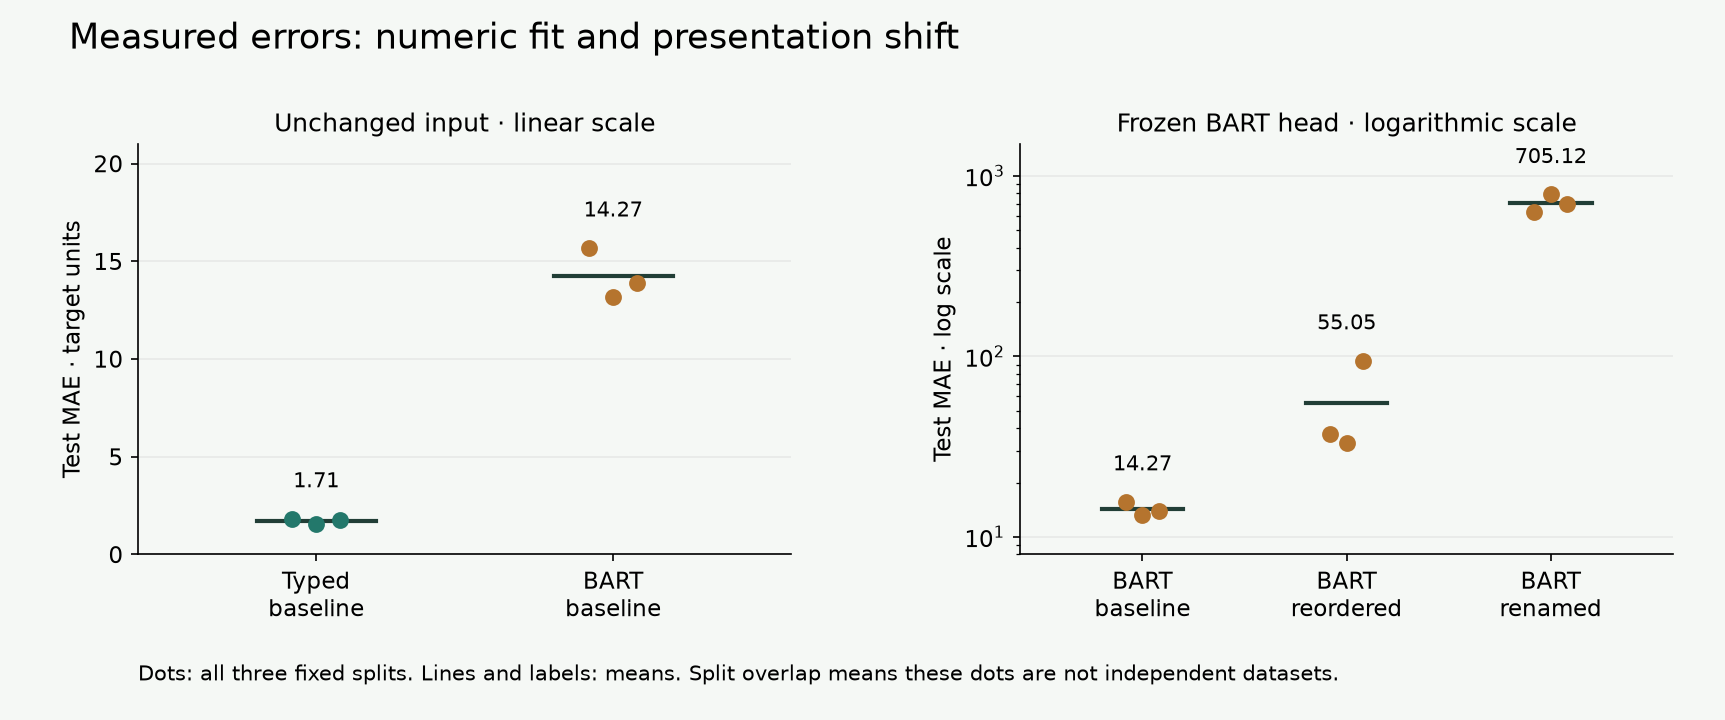<figcaption>Measured synthetic task: every dot is a split score. The left panel is linear; the right is logarithmic to show large schema-shift errors. No intervention retuning. The disclosed additive target favours typed linear features.</figcaption></figure>

**Read the result causally.** The typed path can directly express the target's numeric and categorical terms. Frozen pooled BART features make that relationship less accessible to this head. Renaming also moves representations away from the distribution used to fit the head. Large coefficients or rescaling of low-variance features can amplify such a shift. Our measurements establish the shift and prediction change; they do not isolate each internal cause or prove a general failure of LM encoders.

**Trace one measured prediction shift.** In split seed 0, the first test row is `p086`. Its target is 106.8246. The frozen BART head predicts 121.6190 from the baseline text and −497.9347 after column renaming. No target, numeric value, scaler or head coefficient changed. The prediction shift is about −619.5537 synthetic target units.

For this fixed linear head, each coordinate contributes `coefficient × (renamed_feature − original_feature) / training_scale`. The two largest contributions by absolute size are:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Feature coordinate</th><th>Change after scaling</th><th>Contribution to prediction</th></tr></thead><tbody><tr><td>326</td><td>−22.2731</td><td>+82.4473</td></tr><tr><td>650</td><td>−18.9601</td><td>−42.6215</td></tr><tr><td>Other 766 combined</td><td>—</td><td>−659.3795</td></tr><tr><td>Total</td><td>—</td><td>−619.5537</td></tr></tbody></table>

Coordinate indices are zero-based array positions, not interpretable database fields. For example, coordinate 326 has coefficient −3.7017: two negative factors produce its positive contribution. Contributions can cancel; this decomposition explains the fixed head's arithmetic, not why BART changed its representations. **Try it:** if only coordinate 326 changed, would the prediction fall? **Check:** it would rise by 82.4473 to about 204.0663. The large negative total comes from the combined changes across the representation. [Saved head parameters](https://avistian.github.io/relational/labs/evidence/l163/selection.json) · [Keyed predictions](https://avistian.github.io/relational/labs/evidence/l163/report.json).

The typed scores repeat across presentation variants because the canonical features are identical. The three test sets overlap, so their SD describes split variation and is not a confidence interval. A train-mean baseline, every split score and all 864 keyed predictions are retained in the report. The numeric result does not establish transfer to new databases, unseen categories, missing values, or meaningful free-text tasks.

## 5 · What “full reproduction” means here

**Local experiment:** all rows, three splits, both encoders and both presentation interventions are part of the executable contract. Fresh frozen BART encoding and cached head replay have separate receipts. The notebook defaults to the portable replay so you can inspect and refit the heads cheaply; an explicit cell enables fresh encoding at the pinned revision.

**Historical target:** the paper's Table 1 wikiTables BART_table versus +GNN reconstruction experiment remains **NOT_RUN**. Exact data/splits, matching code/checkpoints and enough training details remain unresolved, so historical fidelity is **NOT_ESTABLISHED**. Our regression comparison is not that experiment, and the paper does not provide a typed-versus-text result to reproduce. [Historical contract](https://avistian.github.io/relational/labs/l163-reproduction.md)

## 6 · Make the comparison yourself

In the student notebook, implement three functions whose outputs are used by the experiment:

1. **`serialize_row`** — allow-list inputs, preserve schema/value association and implement both presentation interventions. CHECK rejects target leakage and broken escaping.
2. **`masked_mean`** — use the real-token mask and reject empty rows. CHECK rejects a plain padded mean. Stored real token states for the first eight rows let your implementation affect the replayed features; the remaining rows use verified pooled features.
3. **`choose_alpha`** — choose from validation losses with a deterministic tie rule. CHECK rejects always choosing the first alpha. The runner uses your choice for all six heads.

Then fill the [comparison template](https://avistian.github.io/relational/labs/l163-comparison-template.md): inputs, fitted/frozen parts, shape, cost, three-split MAE, sensitivity, limitation and next falsifiable test. Explain one schema perturbation before looking at its measured output. A useful next test would add a real free-text task, matched target information and held-out entities; it is a proposal, not evidence supplied here.

Explain the synthetic target bias, schema sensitivity, leakage controls and historical source gap before selecting an encoder.

**EXIT:** defend your encoder choice in 200–300 words. Name the synthetic bias, a leakage control, the difference between fresh encoding and cached replay, and the historical gap. Passing code checks is author/implementation evidence; your reasoning still needs review. Learner status stays **PENDING_WRITTEN_DEFENSE**.

**Spaced retrieval:** tomorrow, derive `[2,5]` from the masked token example without opening the solution. In one week, explain why a presentation-invariant typed feature map does not demonstrate unseen-schema transfer. Ask the teaching agent about any unclear step or submit your table for review.

**Bridge to Lesson 164:** a row encoder supplies local features. A relational foundation model must also decide how to exchange information across rows and tasks. Griffin introduces that next architectural question; neither text serialization nor a typed vector alone creates relational context.


## PROVIDED · Environment
The author used NumPy2.5.0, SciPy1.18.0, scikit-learn1.9.0. The replay records your versions; numerical agreement, not identical bytes across platforms, is the portable criterion. If missing, the bootstrap installs NumPy and scikit-learn. Fresh encoding additionally requires torch, transformers4.57.1 and requests.

In [1]:
# @colab-bootstrap
import os,sys,subprocess,importlib.util
os.environ.update(OMP_NUM_THREADS='1',OPENBLAS_NUM_THREADS='1',MKL_NUM_THREADS='1',TOKENIZERS_PARALLELISM='false')
if any(importlib.util.find_spec(k) is None for k in ['numpy','sklearn']):
    subprocess.check_call([sys.executable,'-m','pip','install','numpy','scikit-learn'])
import io,json,base64,hashlib
from pathlib import Path
import numpy as np
from importlib.metadata import version
print({k:version(k) for k in ['numpy','scipy','scikit-learn']})

{'numpy': '2.5.0', 'scipy': '1.18.0', 'scikit-learn': '1.9.0'}


## PROVIDED · Pinned inputs and real model evidence
240 complete rows and three partitions; all three768-feature arrays; token strings/IDs; final hidden states for the first8 rows in each variant. The encoded payload is only storage. Human-readable functions below perform the computation. Cache hashes guard accidental edits; the source/weight provenance is in the reproduction contract.

In [2]:
payloads={'fixtures.json': '...', 'embeddings.npz': '...', 'pool-states.npz': '...', 'token-traces.json': '...'}
hashes={'fixtures.json': '744e0b7ccce42e92b7a9b88548a09b3f1222a983af7f65f1dcc0885fdcae3f9c', 'embeddings.npz': 'c3a532731d50e48577f600d0943a8fe124dc1c36afc52e2be96ab844a31f594a', 'pool-states.npz': '28259c7473f9d26964c8d1513703f48391d9c3631c684f5a55e7350b0d9b48ef', 'token-traces.json': '37a77458bdcecd7e94d492fc6cae4913cc83ec0fabc0091494c31821d08b3dbf'}
blobs={name:base64.b64decode(value) for name,value in payloads.items()}
for name,raw in blobs.items():
    assert hashlib.sha256(raw).hexdigest()==hashes[name]
packet=json.loads(blobs["fixtures.json"])
arrays=dict(np.load(io.BytesIO(blobs["embeddings.npz"])))
states=dict(np.load(io.BytesIO(blobs["pool-states.npz"])))
token_traces=json.loads(blobs["token-traces.json"])
print("Verified complete 240-row evidence and three splits")

Verified complete 240-row evidence and three splits


## TODO · Allow-list and serialize the row

Require finite numeric price_usd/weight_kg and nonempty string colour/condition. Output compact JSON with table=products then these four fields. Never include id/target. baseline uses canonical order, reordered reverses only the four fields, renamed uses c0..c3 in canonical order. Reject bad inputs/variants with ValueError. Use JSON escaping.

Predict an edge case before writing the implementation.

In [3]:
def serialize_row(row, variant='baseline'):
    """Allow-list the four inputs; target and row identity never enter text."""
    import json, math
    columns=['price_usd','weight_kg','colour','condition']
    if not isinstance(row,dict) or not all(k in row for k in columns):
        raise ValueError('Four canonical input fields required')
    for k in columns[:2]:
        if isinstance(row[k],bool) or not isinstance(row[k],(int,float)) or not math.isfinite(row[k]):
            raise ValueError('Numeric fields must be finite numbers')
    if any(not isinstance(row[k],str) or not row[k] for k in columns[2:]):
        raise ValueError('Categories must be nonempty strings')
    if variant not in ['baseline','reordered','renamed']:raise ValueError('Unknown intervention')
    ordered=list(reversed(columns)) if variant=='reordered' else columns
    payload={'table':'products'}
    for k in ordered:
        name='c'+str(columns.index(k)) if variant=='renamed' else k
        payload[name]=row[k]
    return json.dumps(payload,ensure_ascii=False,separators=(',',':'),allow_nan=False)

In [4]:
# CHECK
q=serialize_row(dict(id='private',price_usd=10.,weight_kg=2.,colour='red',condition='used',target=999))
assert 'private' not in q and '999' not in q and 'target' not in q
print(q)

{"table":"products","price_usd":10.0,"weight_kg":2.0,"colour":"red","condition":"used"}


## TODO · Pool real token states

Accept finite [B,L,D] hidden states and binary [B,L] mask, at least one1 per row. Return [B,D] mean over included tokens, including BOS/EOS. Reject mismatched/nonbinary/all-zero masks with ValueError.

Predict an edge case before writing the implementation.

In [5]:
def masked_mean(hidden, mask):
    """Average final token vectors over real tokens, including BOS/EOS, not PAD."""
    import numpy as np
    h=np.asarray(hidden);m=np.asarray(mask)
    if h.ndim!=3 or m.shape!=h.shape[:2] or not np.isfinite(h).all():
        raise ValueError('Expected finite [batch,tokens,width] and aligned mask')
    if not np.isin(m,[0,1]).all() or (m.sum(axis=1)==0).any():
        raise ValueError('Binary mask with at least one included token per row required')
    return (h*m[:,:,None]).sum(axis=1)/m.sum(axis=1)[:,None]

In [6]:
# CHECK
np.testing.assert_allclose(masked_mean([[[1.,3.],[3.,7.],[900.,900.]]],[[1,1,0]]),[[2,5]])
print('CHECK: padding excluded')

CHECK: padding excluded


## TODO · Select without test labels

Accept nonempty aligned 1D positive alphas and finite nonnegative validation MAEs. Return the alpha with smallest error, first in supplied order on a tie. Reject invalid inputs with ValueError.

Predict an edge case before writing the implementation.

In [7]:
def choose_alpha(alphas, validation_mae):
    """Only validation losses enter this interface; ties retain first grid entry."""
    import numpy as np
    a=np.asarray(alphas,dtype=float);v=np.asarray(validation_mae,dtype=float)
    if a.ndim!=1 or not len(a) or a.shape!=v.shape or not np.isfinite(a).all() or not np.isfinite(v).all() or (a<=0).any() or (v<0).any():
        raise ValueError('Positive alphas and aligned finite nonnegative validation errors required')
    return float(a[int(np.argmin(v))])

In [8]:
# CHECK
assert choose_alpha([.01,.1,1.],[3,1,2])==.1
assert choose_alpha([.01,.1],[1,1])==.01
print('CHECK: validation choice and stable tie')

CHECK: validation choice and stable tie


## PROVIDED · Train-only typed representation

In [9]:
def typed_features(train_rows, rows):
    """Train-only numeric moments plus train-only one-hot vocabularies."""
    import numpy as np
    if not train_rows or not rows:raise ValueError('Nonempty training and query rows required')
    for row in train_rows+rows:serialize_row(row)
    numeric=['price_usd','weight_kg'];categorical=['colour','condition']
    train=np.asarray([[r[k] for k in numeric] for r in train_rows],dtype=float)
    mean=train.mean(axis=0);scale=train.std(axis=0);scale[scale==0]=1.
    vocab={k:sorted({r[k] for r in train_rows}) for k in categorical}
    numbers=(np.asarray([[r[k] for k in numeric] for r in rows])-mean)/scale
    onehot=np.asarray([[float(r[k]==v) for k in categorical for v in vocab[k]] for r in rows])
    return np.concatenate([numbers,onehot],axis=1),dict(mean=mean.tolist(),scale=scale.tolist(),categories=vocab)

In [10]:
def check163(serialize, pool, choose, typed):
    import json, numpy as np
    row=dict(id='never_encode_001',price_usd=10.0,weight_kg=2.5,colour='red',condition='used',target=999999)
    s=serialize(row)
    assert 'never_encode' not in s and 'target' not in s and '999999' not in s
    assert json.loads(s)==dict(table='products',price_usd=10.0,weight_kg=2.5,colour='red',condition='used')
    assert list(json.loads(serialize(row,'reordered')))==['table','condition','colour','weight_kg','price_usd']
    assert json.loads(serialize(row,'renamed'))==dict(table='products',c0=10.0,c1=2.5,c2='red',c3='used')
    weird=dict(row,colour='red"; target=9\n雪');assert json.loads(serialize(weird))['colour']==weird['colour']
    assert row['target']==999999
    h=np.array([[[1.,3.],[3.,7.],[900.,900.]],[[8.,2.],[0.,0.],[0.,0.]]])
    m=np.array([[1,1,0],[1,0,0]])
    np.testing.assert_allclose(pool(h,m),[[2,5],[8,2]])
    np.testing.assert_allclose(pool(h[:,:2],m[:,:2]),[[2,5],[8,2]])
    assert choose([.01,.1,1],[4,2,3])==.1
    assert choose([.01,.1,1],[2,2,3])==.01
    a=dict(row,price_usd=0.,weight_kg=1.,colour='blue',condition='new')
    b=dict(row,price_usd=10.,weight_kg=3.)
    # The large held-out value must never refit training moments or vocabularies.
    x,meta=typed([a,b],[a,b,dict(row,price_usd=100.,weight_kg=5.,colour='unseen')])
    np.testing.assert_allclose(x[:,:2],[[-1,-1],[1,1],[19,3]])
    assert meta['categories']=={'colour':['blue','red'],'condition':['new','used']}
    np.testing.assert_array_equal(x[2,2:4],[0,0])
    assert typed([a,b],[a,b])[1]==meta
    for operation in [lambda:serialize(row,'oops'),lambda:serialize(dict(row,price_usd=float('nan'))),lambda:serialize({}),lambda:pool(h,np.zeros((2,3))),lambda:pool(h,[[1,2,0],[1,0,0]]),lambda:choose([1],[float('nan')]),lambda:choose([],[]),lambda:choose([1,2],[1]),lambda:typed([],[]),lambda:pool(h,[[1,1]])]:
        try:operation()
        except ValueError:pass
        else:raise AssertionError('Invalid input accepted')
    return 'PASS'

In [11]:
assert check163(serialize_row,masked_mean,choose_alpha,typed_features)=='PASS'
# Your serializer must recover the exact measured input for every cached row.
for variant in packet['variants']:
    for row,trace in zip(packet['rows'],token_traces[variant]):
        assert serialize_row(row,variant)==trace['text']
    # Your pooling implementation supplies real features for the first8 rows.
    repooled=masked_mean(states[variant+'_hidden'],states[variant+'_mask']).astype(np.float32)
    np.testing.assert_allclose(repooled,arrays[variant][:8],atol=1e-6,rtol=1e-6)
    arrays[variant][:8]=repooled
print('PASS: 720 serializations and 24 live real-state pooled rows')

PASS: 720 serializations and 24 live real-state pooled rows


## PROVIDED · Optional fresh frozen encoding
Default False replays the verified author cache. Set True only when you want to download the pinned model and recompute all720 representations on CPU; this is distinct from head replay and does not train BART. Dependencies/device affect runtime. No historical trainer is implied.

In [12]:
def fetch_model(packet, destination):
    import hashlib,json,requests
    from pathlib import Path
    destination=Path(destination);destination.mkdir(parents=True,exist_ok=True)
    artifacts=[]
    for name in ['config.json','vocab.json','merges.txt','tokenizer.json','model.safetensors']:
        path=destination/name
        url='https://huggingface.co/'+packet['model_id']+'/resolve/'+packet['revision']+'/'+name
        if not path.exists():
            response=requests.get(url,stream=True,timeout=(30,90));response.raise_for_status()
            tmp=path.with_suffix(path.suffix+'.partial')
            with tmp.open('wb') as out:
                for chunk in response.iter_content(1024*1024):out.write(chunk)
            tmp.replace(path)
        digest=hashlib.file_digest(path.open('rb'),'sha256').hexdigest()
        artifacts.append(dict(file=name,sha256=digest,bytes=path.stat().st_size,url=url))
    return artifacts

In [13]:
def encode_rows(packet, model_path, serialize, pool):
    import time, numpy as np, torch
    from transformers import BartTokenizerFast, BartModel
    torch.set_num_threads(1)
    tokenizer=BartTokenizerFast.from_pretrained(str(model_path),local_files_only=True)
    model=BartModel.from_pretrained(str(model_path),local_files_only=True,attn_implementation='eager').float().eval()
    model.requires_grad_(False);encoder=model.get_encoder()
    assert model.config.d_model==768 and model.config.encoder_layers==6 and model.config.max_position_embeddings==1024
    arrays={};traces={};timings={};parity=[]
    for variant in packet['variants']:
        texts=[serialize(row,variant) for row in packet['rows']];outputs=[];records=[];start=time.perf_counter()
        for pos in range(0,len(texts),packet['batch_size']):
            batch=texts[pos:pos+packet['batch_size']]
            tokens=tokenizer(batch,padding=True,truncation=False,return_tensors='pt')
            if tokens.input_ids.shape[1]>packet['max_length']:raise ValueError('Overlength row; no silent truncation allowed')
            with torch.inference_mode():hidden=encoder(**tokens).last_hidden_state
            pooled=pool(hidden.numpy(),tokens.attention_mask.numpy())
            # Independent torch reduction; catches NumPy pooling errors on real states.
            reference=(hidden*tokens.attention_mask[:,:,None]).sum(1)/tokens.attention_mask.sum(1)[:,None]
            np.testing.assert_allclose(pooled,reference.numpy(),atol=2e-6,rtol=2e-6)
            outputs.append(pooled.astype(np.float32))
            for j,text in enumerate(batch):
                ids=tokens.input_ids[j][tokens.attention_mask[j].bool()].tolist()
                records.append(dict(id=packet['rows'][pos+j]['id'],text=text,token_ids=ids,tokens=tokenizer.convert_ids_to_tokens(ids),length=len(ids)))
        arrays[variant]=np.concatenate(outputs);traces[variant]=records;timings[variant]=time.perf_counter()-start
        # Same first row alone: padding/batch composition should not materially change it.
        token=tokenizer(texts[0],return_tensors='pt')
        with torch.inference_mode():h=encoder(**token).last_hidden_state.numpy()
        alone=pool(h,token.attention_mask.numpy())[0]
        diff=float(np.max(np.abs(alone-arrays[variant][0])))
        np.testing.assert_allclose(alone,arrays[variant][0],atol=1e-5,rtol=1e-5);parity.append(dict(variant=variant,max_abs_difference=diff))
        print(variant,arrays[variant].shape,'seconds',round(timings[variant],2),flush=True)
    return arrays,traces,dict(seconds=timings,batch_padding_parity=parity,encoder_width=768,encoder_layers=6,model_parameters=sum(p.numel() for p in model.parameters()),trainable_parameters=sum(p.numel() for p in model.parameters() if p.requires_grad),device='cpu',dtype='float32')

In [14]:
RUN_FRESH_ENCODER=False
if RUN_FRESH_ENCODER:
    subprocess.check_call([sys.executable,'-m','pip','install','transformers==4.57.1','torch','requests'])
    model_path=Path('l163-model')/packet['revision']
    downloaded_artifacts=fetch_model(packet,model_path)
    arrays,token_traces,fresh_receipt=encode_rows(packet,model_path,serialize_row,masked_mean)
    Path('l163-fresh-receipt.json').write_text(json.dumps(dict(fresh_receipt,artifacts=downloaded_artifacts),indent=2))
    print('Fresh frozen encoding complete')
else:
    print('CACHE_REPLAY: no fresh encoding performed by this notebook run')

CACHE_REPLAY: no fresh encoding performed by this notebook run


## PROVIDED · Fit on train, select on validation, freeze, then test
Your choose_alpha implementation selects all six heads. Intervention inputs never retune the baseline heads. The stored selection receipt precedes test computation.

In [15]:
def fit_heads(packet, arrays, typed, choose):
    import numpy as np
    from sklearn.linear_model import Ridge
    from sklearn.preprocessing import StandardScaler
    rows=packet['rows'];y=np.asarray([r['target'] for r in rows]);frozen=[]
    for split in packet['splits']:
        tr=split['train'];va=split['validation']
        typed_x,meta=typed([rows[i] for i in tr],rows)
        for method,x in [('typed',typed_x),('bart',arrays['baseline'])]:
            x=np.asarray(x,dtype=np.float64)  # stable head replay; encoder cache remains float32
            scaler=StandardScaler().fit(x[tr]);train=scaler.transform(x[tr]);valid=scaler.transform(x[va])
            candidates=[Ridge(alpha=a,solver='svd').fit(train,y[tr]) for a in packet['alphas']]
            errors=[float(np.mean(np.abs(y[va]-model.predict(valid)))) for model in candidates]
            alpha=choose(packet['alphas'],errors);model=candidates[packet['alphas'].index(alpha)]
            frozen.append(dict(seed=split['seed'],method=method,alpha=alpha,validation_mae=errors,
              feature_mean=scaler.mean_.tolist(),feature_scale=scaler.scale_.tolist(),coef=model.coef_.tolist(),intercept=float(model.intercept_),
              typed_metadata=meta if method=='typed' else None,train_mean_target=float(y[tr].mean())))
    return frozen

In [16]:
def evaluate_heads(packet, arrays, heads, typed):
    import numpy as np
    rows=packet['rows'];y=np.asarray([r['target'] for r in rows]);results=[];predictions=[]
    for head in heads:
        split=next(s for s in packet['splits'] if s['seed']==head['seed']);test=split['test'];train=split['train']
        typed_x,_=typed([rows[i] for i in train],rows);baseline_pred=None
        for variant in packet['variants']:
            # Canonical field identities are retained for the typed representation.
            x=typed_x if head['method']=='typed' else arrays[variant]
            pred=((x[test]-np.asarray(head['feature_mean']))/np.asarray(head['feature_scale']))@np.asarray(head['coef'])+head['intercept']
            if variant=='baseline':baseline_pred=pred.copy()
            mae=float(np.abs(pred-y[test]).mean())
            results.append(dict(seed=head['seed'],method=head['method'],variant=variant,alpha=head['alpha'],test_mae=mae,
                train_mean_baseline_mae=float(np.abs(y[test]-head['train_mean_target']).mean()),prediction_change=float(np.abs(pred-baseline_pred).mean())))
            for i,estimate in zip(test,pred):predictions.append(dict(seed=head['seed'],method=head['method'],variant=variant,id=rows[i]['id'],target=float(y[i]),prediction=float(estimate),absolute_error=float(abs(estimate-y[i]))))
    summary=[]
    for method in ['typed','bart']:
        for variant in packet['variants']:
            r=[v for v in results if v['method']==method and v['variant']==variant]
            summary.append(dict(method=method,variant=variant,mean_mae=float(np.mean([v['test_mae'] for v in r])),sample_sd=float(np.std([v['test_mae'] for v in r],ddof=1)),mean_prediction_change=float(np.mean([v['prediction_change'] for v in r]))))
    return dict(experiment=packet['experiment'],status='COMPLETE',scope=packet['scope'],results=results,summary=summary,predictions=predictions,
      row_count=len(rows),split_seeds=[s['seed'] for s in packet['splits']],historical_reproduction='NOT_RUN',historical_fidelity='NOT_ESTABLISHED',general_encoder_superiority='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE',cloud_spend_usd=0)

In [17]:
def render_report(report):
    lines=['# L163 Frozen Row Encoder Comparison','', 'Executed synthetic regression task. MAE in synthetic target units; lower is better.','', '| Encoder | Input variant | Mean MAE | Split SD | Mean prediction change |','|---|---|---:|---:|---:|']
    for r in report['summary']:lines.append(f"| {r['method']} | {r['variant']} | {r['mean_mae']:.6f} | {r['sample_sd']:.6f} | {r['mean_prediction_change']:.6f} |")
    lines+=['','| Split | Encoder | Input | Alpha | Test MAE | Train-mean baseline MAE |','|---:|---|---|---:|---:|---:|']
    for r in report['results']:lines.append(f"| {r['seed']} | {r['method']} | {r['variant']} | {r['alpha']} | {r['test_mae']:.6f} | {r['train_mean_baseline_mae']:.6f} |")
    lines+=['','Three overlapping splits are not independent datasets; SD is descriptive, not a confidence interval. The target is explicitly numeric/additive, favoring the typed linear path. No LM fine-tuning, natural text semantics, missing-data comparison, GNN or database transfer is tested.','', 'All 864 keyed predictions are in report.json. Six heads were selected on validation before test evaluation. Reordered and renamed inputs use unchanged baseline heads. Historical reproduction NOT_RUN; fidelity and general superiority NOT_ESTABLISHED. Learner PENDING_WRITTEN_DEFENSE.']
    return '\n'.join(lines)+'\n'

In [18]:
heads=fit_heads(packet,arrays,typed_features,choose_alpha)
Path('l163-selection.json').write_text(json.dumps(heads,indent=2))
report=evaluate_heads(packet,arrays,heads,typed_features)
assert len(report['predictions'])==864
print(render_report(report))
Path('l163-report.json').write_text(json.dumps(report,indent=2)+'\n')

# L163 Frozen Row Encoder Comparison

Executed synthetic regression task. MAE in synthetic target units; lower is better.

| Encoder | Input variant | Mean MAE | Split SD | Mean prediction change |
|---|---|---:|---:|---:|
| typed | baseline | 1.713803 | 0.151146 | 0.000000 |
| typed | reordered | 1.713803 | 0.151146 | 0.000000 |
| typed | renamed | 1.713803 | 0.151146 | 0.000000 |
| bart | baseline | 14.265465 | 1.285415 | 0.000000 |
| bart | reordered | 55.050553 | 34.406235 | 50.765346 |
| bart | renamed | 705.121763 | 81.465686 | 705.387827 |

| Split | Encoder | Input | Alpha | Test MAE | Train-mean baseline MAE |
|---:|---|---|---:|---:|---:|
| 0 | typed | baseline | 0.01 | 1.835880 | 95.064468 |
| 0 | typed | reordered | 0.01 | 1.835880 | 95.064468 |
| 0 | typed | renamed | 0.01 | 1.835880 | 95.064468 |
| 0 | bart | baseline | 0.01 | 15.691710 | 95.064468 |
| 0 | bart | reordered | 0.01 | 37.219269 | 95.064468 |
| 0 | bart | renamed | 0.01 | 626.908089 | 95.064468 |
| 1 | typed 

196641

## EXIT · Encoder-comparison table and written defense
Use the lesson template. Include each split, representation shape, fitted/frozen parts, input cost, presentation sensitivity and a falsifiable follow-up. Explain the additive target bias, test-label isolation, cached versus fresh evidence and historical source gaps in200–300 words. Rubric: computation, legality, causality, evidence, next test;0–2 each;≥8/10 with no zero after review. The short author illustration is not a completed learner submission.

In [19]:
defense='For this additive numeric task I would use the typed baseline. It exposes the actual numeric and category terms directly, whereas the frozen BART path adds a token/representation mapping whose linear readout has higher measured error. Canonical typed field lookup explains presentation invariance; it is not unseen-schema transfer. The experiment does not test rich text semantics. I would require a matched free-text task before generalizing the choice. Fresh encoding and cached head replay are distinct; the historical wikiTables trainer is source-gated.'
Path("l163-submission.json").write_text(json.dumps(dict(defense=defense,review=None,learner="PENDING_WRITTEN_DEFENSE"),indent=2))
print("Exported defense; learner PENDING_WRITTEN_DEFENSE")

Exported defense; learner PENDING_WRITTEN_DEFENSE
